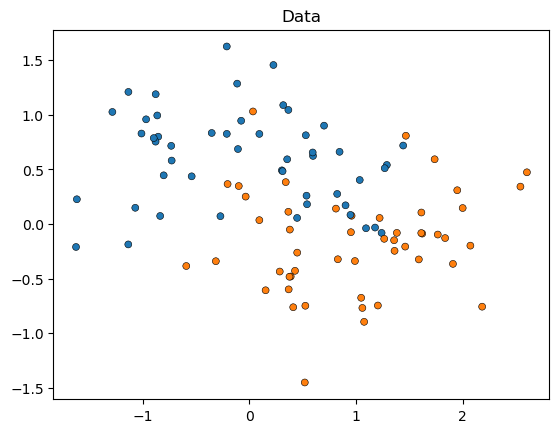

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold
from sklearn.svm import SVC
import pandas as pd
# Generate moon-shaped data
X, y = make_moons(noise=0.352, random_state=1, n_samples=100)
# Plot the data
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, marker="o", s=25, edgecolor="k", legend=False).set_title("Data")
plt.show()

In [3]:
# Define the parameter grid
param_grid = [
   {"kernel": ["linear"]},
   {"kernel": ["poly"], "degree": [2, 3]},
   {"kernel": ["rbf"]}
]
# Create the SVC model
svc = SVC(random_state=0)
# Define the cross-validation strategy
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=10, random_state=0)
# Create the GridSearchCV object
search = GridSearchCV(estimator=svc, param_grid=param_grid, scoring="roc_auc", cv=cv)

In [4]:
# Fit the GridSearchCV object
search.fit(X, y)
# Extract the results
results_df = pd.DataFrame(search.cv_results_)
results_df = results_df.sort_values(by=["rank_test_score"])
results_df = results_df.set_index(results_df["params"].apply(lambda x: "_".join(str(val) for val in x.values()))).rename_axis("kernel")
results_df[["params", "rank_test_score", "mean_test_score", "std_test_score"]]

,params,rank_test_score,mean_test_score,std_test_score
kernel,,,,
rbf,{'kernel': 'rbf'},1,0.9400,0.079297
linear,{'kernel': 'linear'},2,0.9300,0.077846
3_poly,"{'degree': 3, 'kernel': 'poly'}",3,0.9044,0.098776
2_poly,"{'degree': 2, 'kernel': 'poly'}",4,0.6852,0.169106


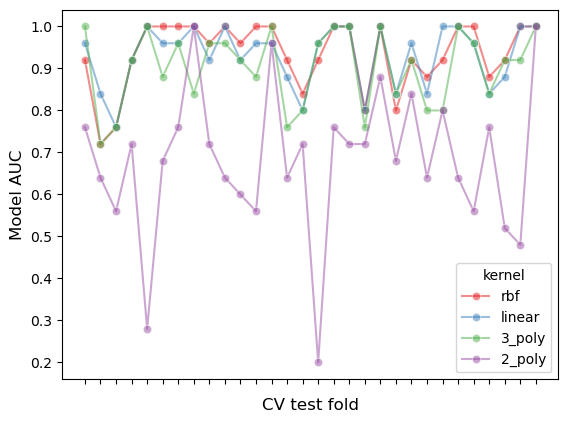

In [5]:
# Create a DataFrame of model scores ordered by performance
model_scores = results_df.filter(regex=r"split\d*_test_score")
# Plot the performance of all models in each fold
fig, ax = plt.subplots()
sns.lineplot(data=model_scores.transpose().iloc[:30], dashes=False, palette="Set1", marker="o", alpha=0.5, ax=ax)
ax.set_xlabel("CV test fold", size=12, labelpad=10)
ax.set_ylabel("Model AUC", size=12)
ax.tick_params(bottom=True, labelbottom=False)
plt.show()